In [2]:
pip install rasterio scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/25.4 MB ? eta -:--:--
    --------------------------------------- 0.5/25.4 MB 3.4 MB/s eta 0:00:08
   -- ------------------------------------- 1.8/25.4 MB 5.9 MB/s eta 0:00:04
   ---- ----------------------------------- 3.1/25.4 MB 6.1 MB/s eta 0:00:04
   ------ --------------------------------- 3.9/25.4 MB 5.6 MB/s eta 0:00:04
   -------- ------------------------------- 5.5/25.4 MB 5.7 MB/s eta 0:00:04
   ---------- ----------------------------- 6.8/25.4 MB 6.1 MB/s eta 0:00:04
   ------------- -------------------------- 8.7/25.4 MB 6.3 MB/s eta 0:00:03
   -------------- ------------------------- 9.4/25.4 MB 6.5 MB/s eta 0:00:03
   ---------------- ----------------------- 10.5/25.4 MB 5.8 MB/s eta 0:00:03
   ----------------- ---------------------- 11.0/25.4 MB 5.5 MB/s eta 0:00:03
   ------------------ --------------------- 11.8/25.4 MB 5.3 MB/s eta 0:00:03
  


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\neela\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Import libraries
import os
import rasterio
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.enums import Resampling

In [8]:
# Paths
raster_dir = "C:\\Users\\neela\\Desktop\\2025\\Crop Predicion\\DATA"  # Directory with GeoTIFFs
input_csv = r"C:\Users\neela\Desktop\2025\Crop Predicion\DATA\extracted3004.csv"  # Your extracted CSV
output_yield_tiff = r"C:\Users\neela\Desktop\2025\Crop Predicion\DATA\spatial_yield_prediction3.tif"  # Output yield map


In [9]:
# 1 Load CSV Data
data = pd.read_csv(input_csv)
print("CSV data loaded successfully.")
print(data.head())

# Drop 'geometry' column if present
data = data.drop(columns=['geometry'], errors='ignore')

CSV data loaded successfully.
   yield      ndvi      NDRE       EVI     SAVI1     fapar       LAI       VH  \
0   3625  0.049711 -0.009231  0.081419  0.272384  0.311875  0.249342 -14.8738   
1   3489  0.118851  0.056017  0.110358  0.297507  0.351250  0.289430 -16.2306   
2   3623  0.181133  0.108763  0.254729  0.372230  0.361250  0.542861 -13.7459   
3   3654  0.025147  0.085688  0.110914  0.190414  0.385000  0.431830 -17.8357   
4   5086  0.130867 -0.012848  0.080940  0.361681  0.415000  0.293606 -14.7982   

         VV   entropy    alpha       rvi    rfcum  humidity  solarrad  \
0 -22.42280  0.592264  15.5620  0.354469  243.792   70.1660  13646300   
1 -11.20860  0.644759  17.3473  0.395251  245.324   69.9258  13575000   
2  -8.70621  0.662985  18.2631  0.411245  245.324   70.1461  13667300   
3 -14.14650  0.687249  18.5192  0.448985  284.378   70.1751  13572800   
4  -9.36604  0.598385  15.9679  0.450272  243.792   70.2494  13667300   

   gddcumulative   cc  nitro  pH    OC  
0  

In [10]:
# Prepare Features and Target
feature_names = [col for col in data.columns if col.lower() != 'yield']
X = data[feature_names]
y = data['yield']

print("\n Features prepared:")
print(X.columns.tolist())


 Features prepared:
['ndvi', 'NDRE', 'EVI', 'SAVI1', 'fapar', 'LAI', 'VH', 'VV', 'entropy', 'alpha', 'rvi', 'rfcum', 'humidity', 'solarrad', 'gddcumulative', 'cc', 'nitro', 'pH', 'OC']


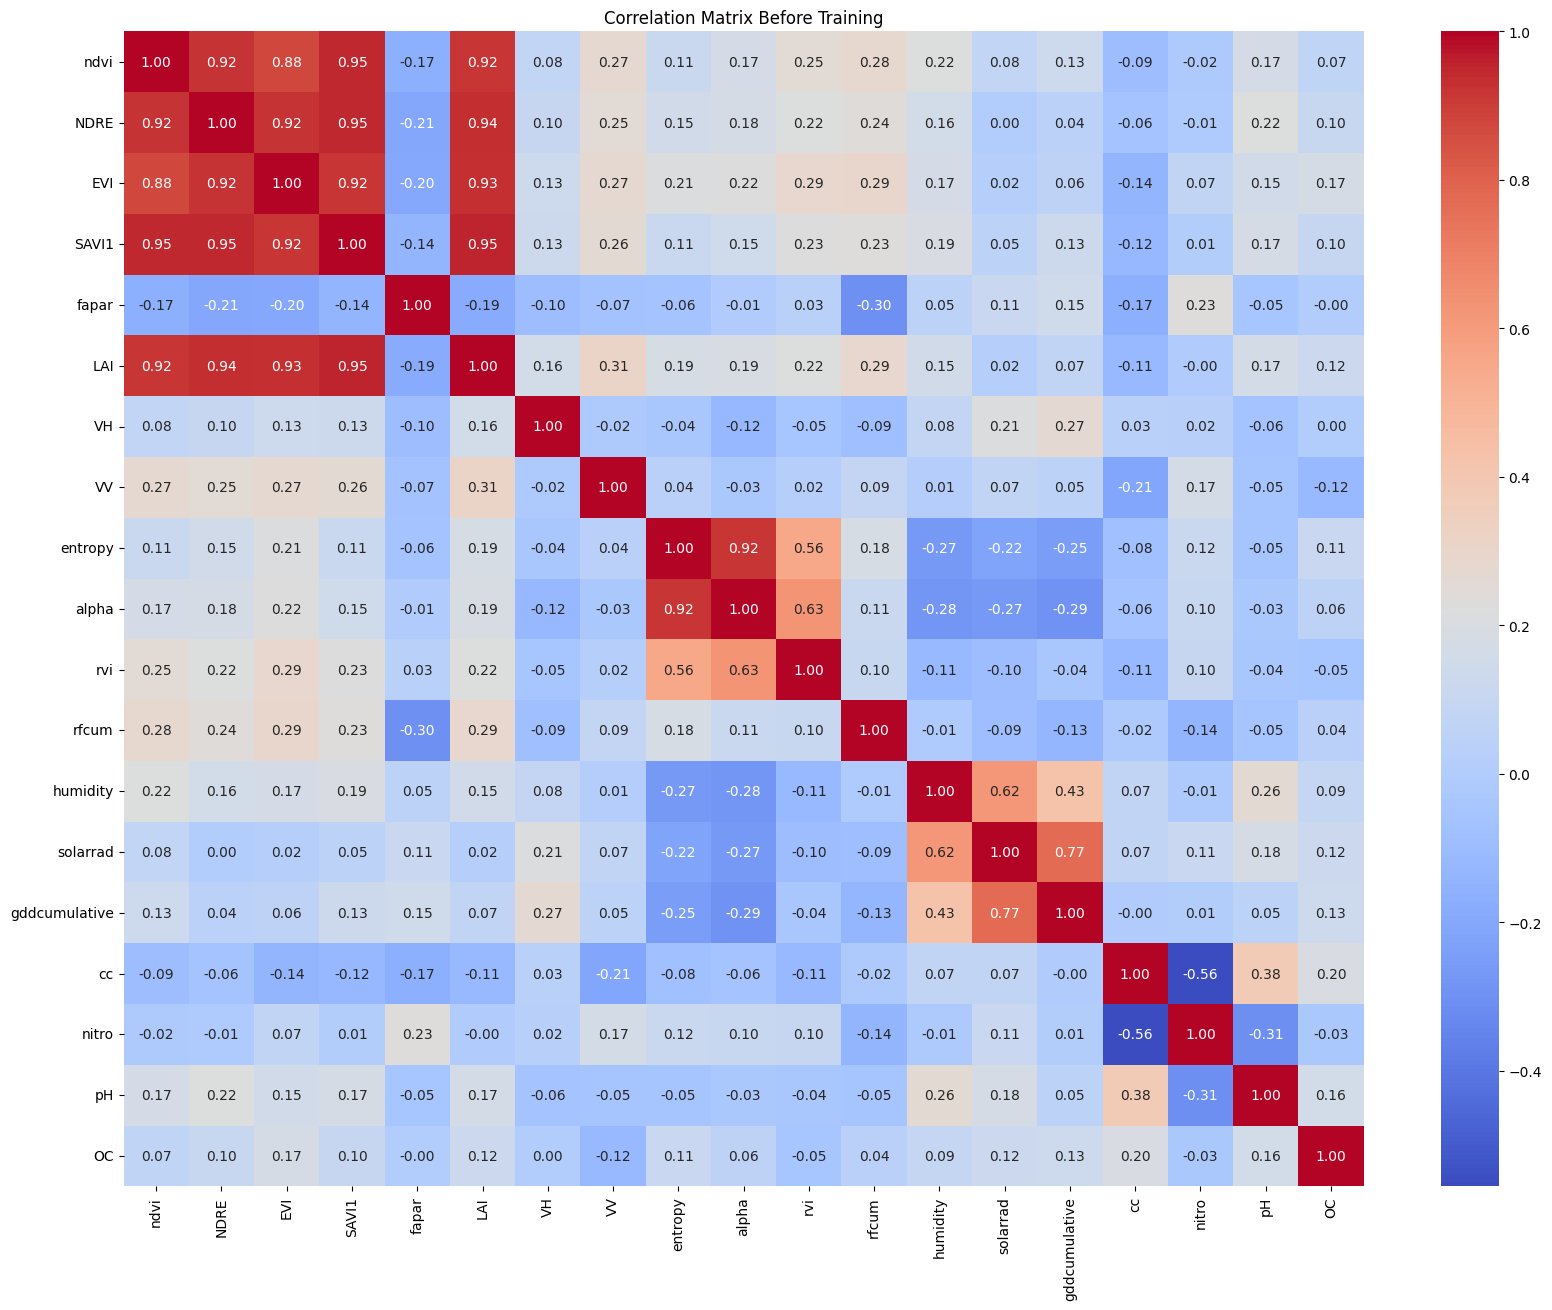

In [11]:
# 2️ Exploratory Data Analysis (EDA)

# 2.1 Correlation Matrix
plt.figure(figsize=(20, 15))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix Before Training")
plt.show()


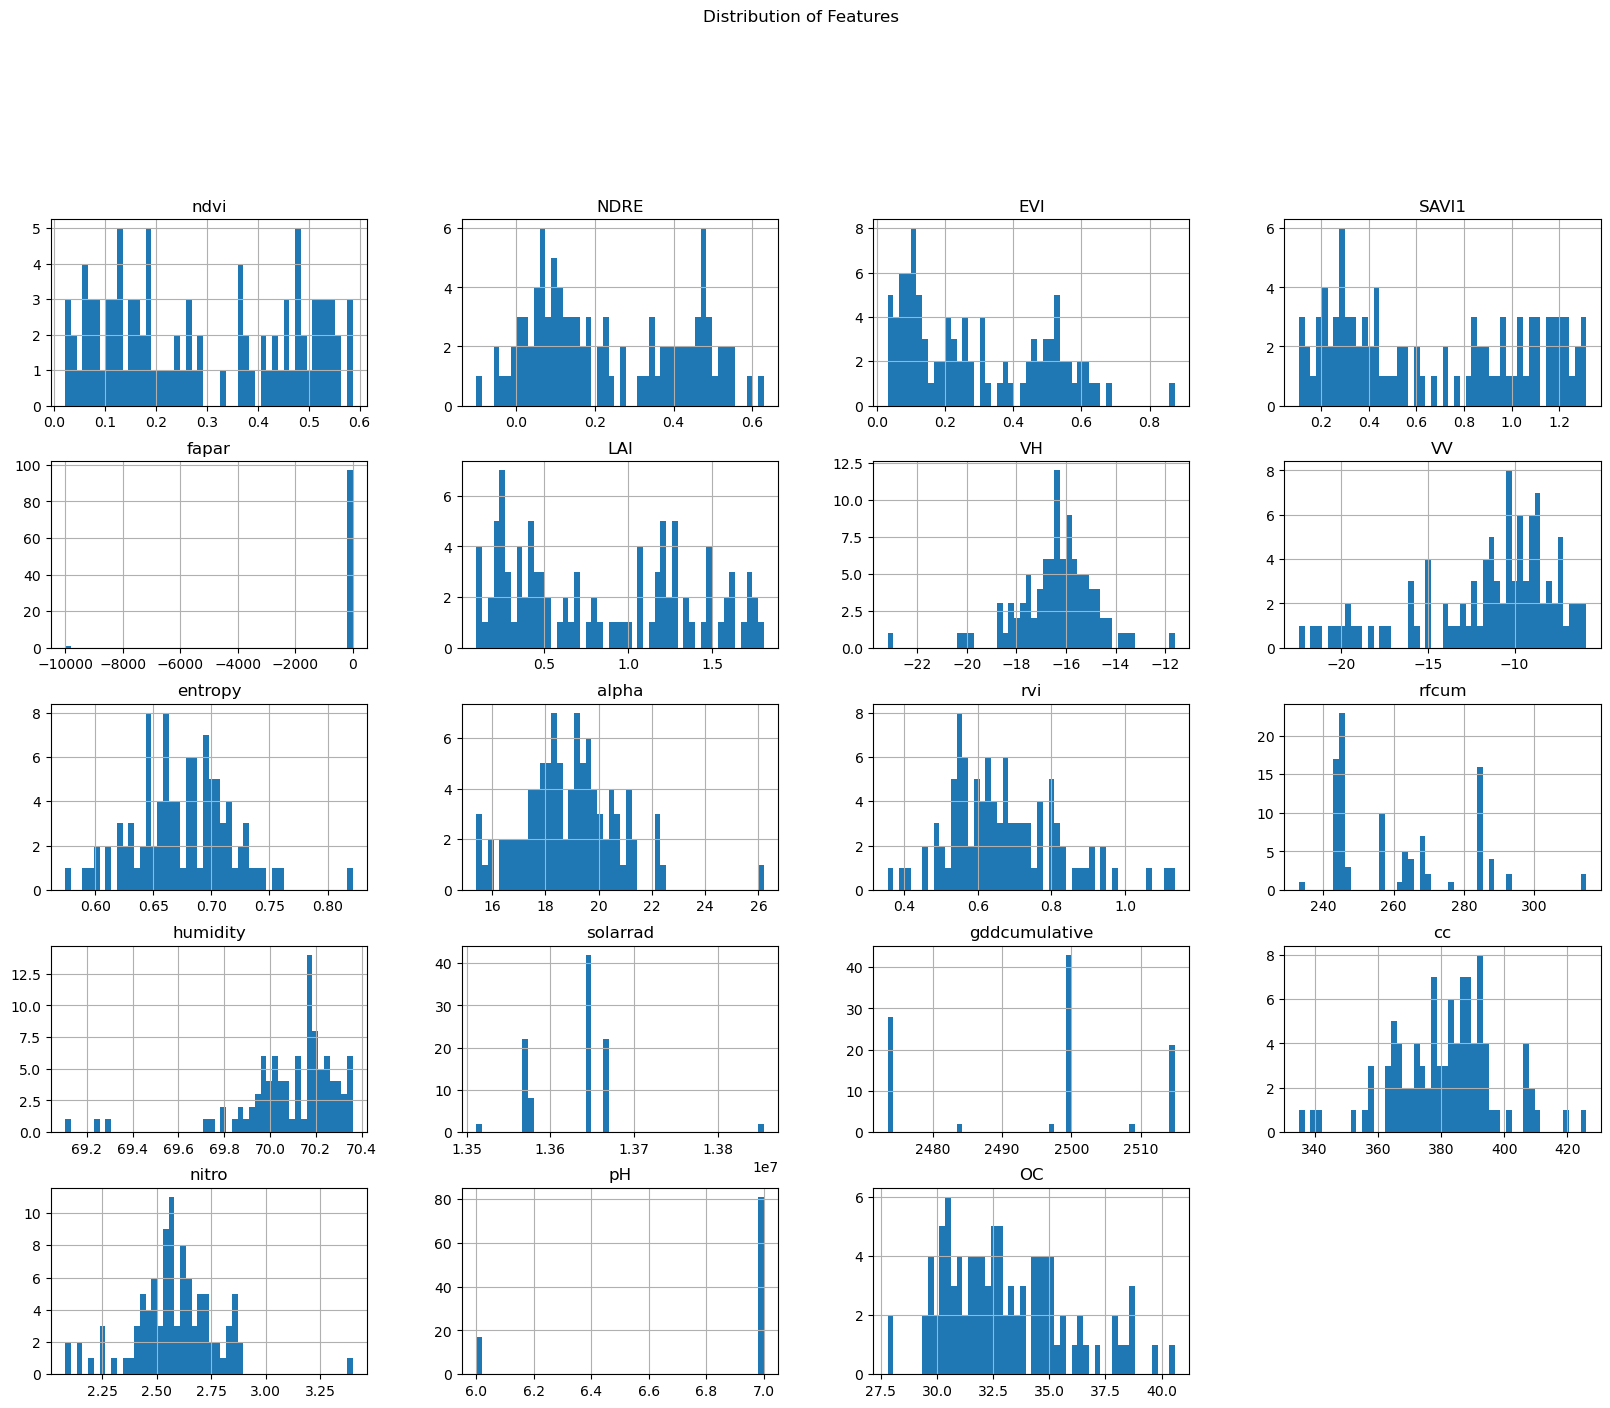

In [54]:
# 2.2 Histograms of All Features
X.hist(bins=50, figsize=(20,15))
plt.suptitle("Distribution of Features", y=1.02)
plt.show()

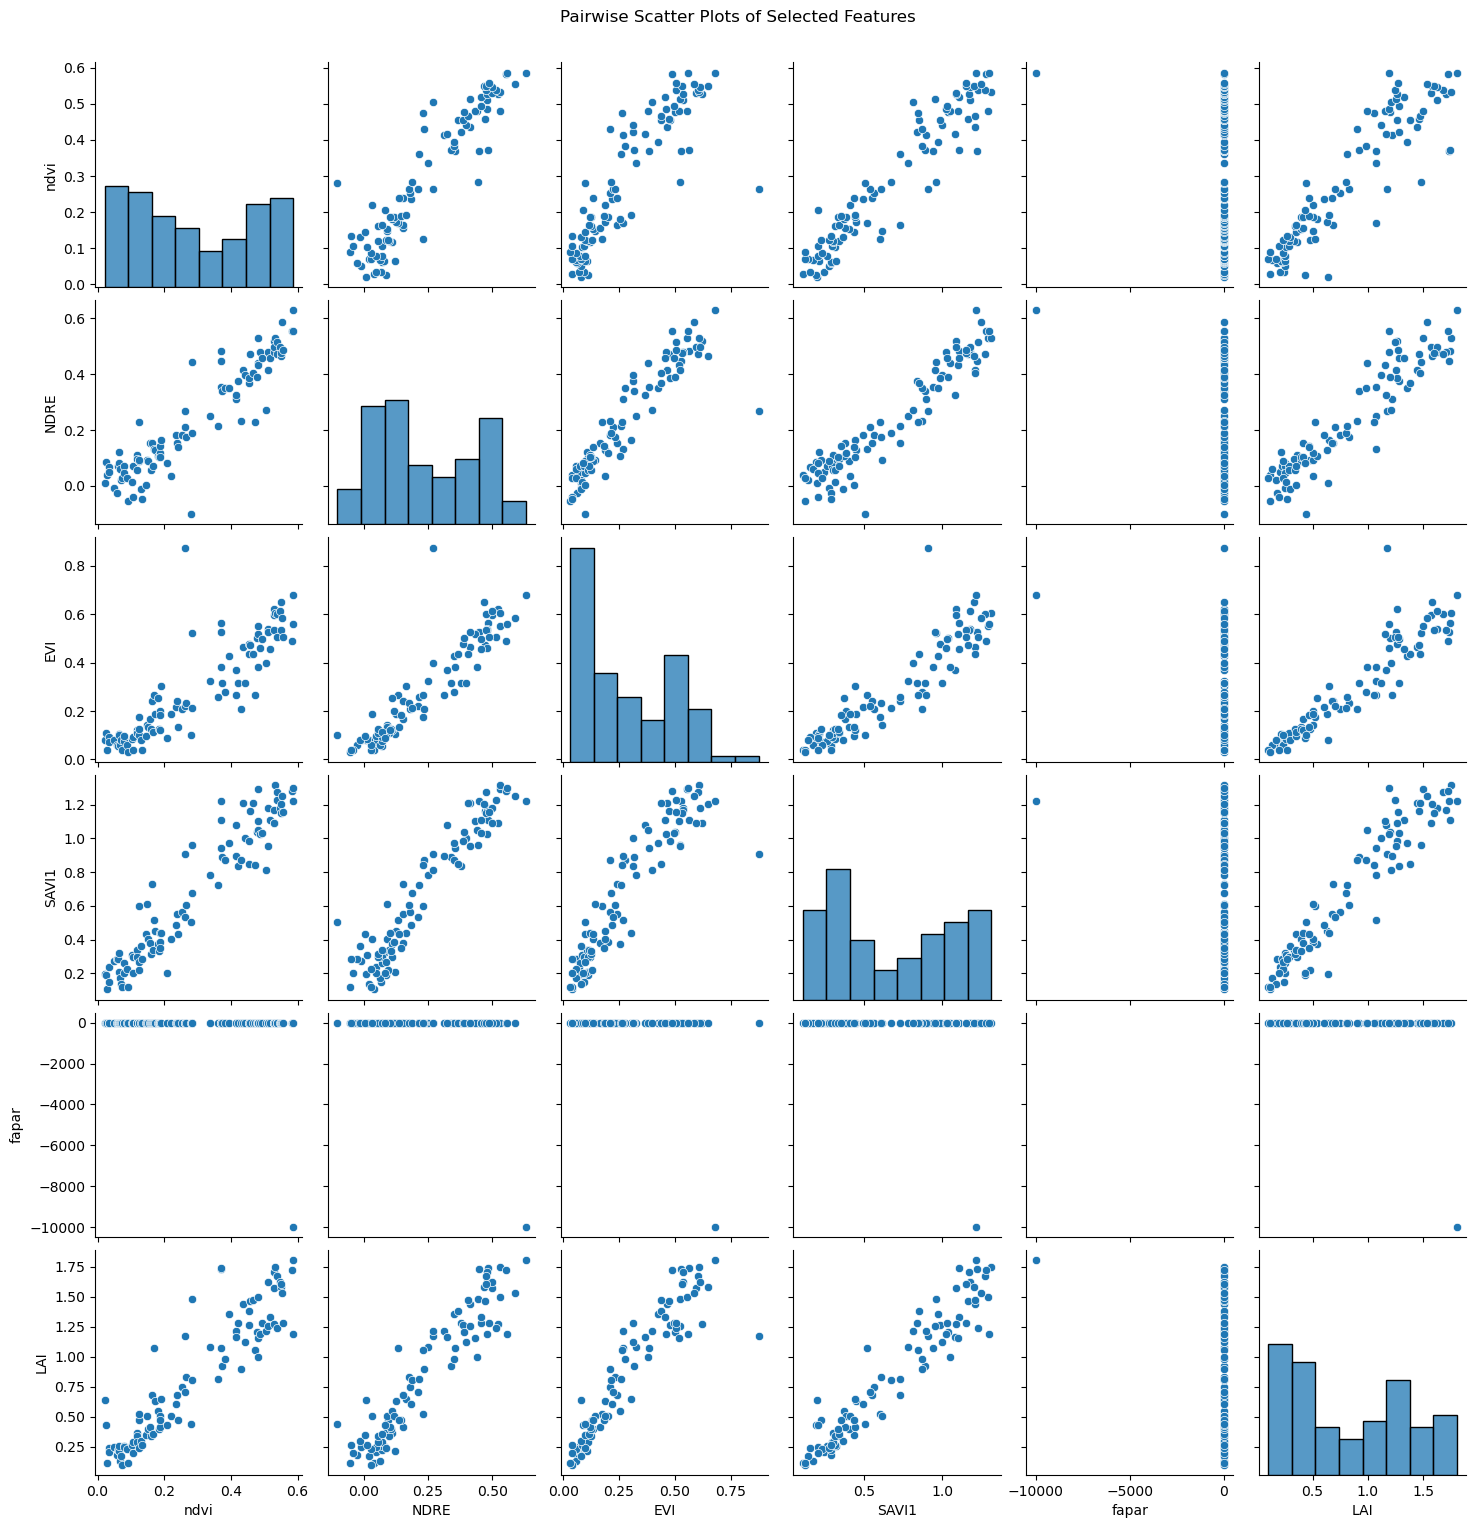

In [42]:
# 2.3 Pairwise Scatter Plots (Pairplot)
selected_features = X.columns[:6]  # Choose first 6 features for clarity
sns.pairplot(X[selected_features])
plt.suptitle("Pairwise Scatter Plots of Selected Features", y=1.02)
plt.show()

In [55]:
# 3️ Normalize Features (Min-Max Scaling)
scaler = MinMaxScaler()
X_normalized = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [56]:
# 4️ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)
print(f"\n Train size: {len(X_train)}, Test size: {len(X_test)}")


 Train size: 78, Test size: 20


In [57]:
# 5️ Hyperparameter Tuning using RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200, 500, 1000],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_
print("\n Best parameters found:", rf_random.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Best parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}


In [58]:
# 6️ Evaluate Model on Test Data
y_pred = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n Model Evaluation Metrics:")
print(f" - R² Score: {r2:.4f}")
print(f" - RMSE: {rmse:.2f}")
print(f" - MAE: {mae:.2f}")



 Model Evaluation Metrics:
 - R² Score: 0.6258
 - RMSE: 760.48
 - MAE: 553.41


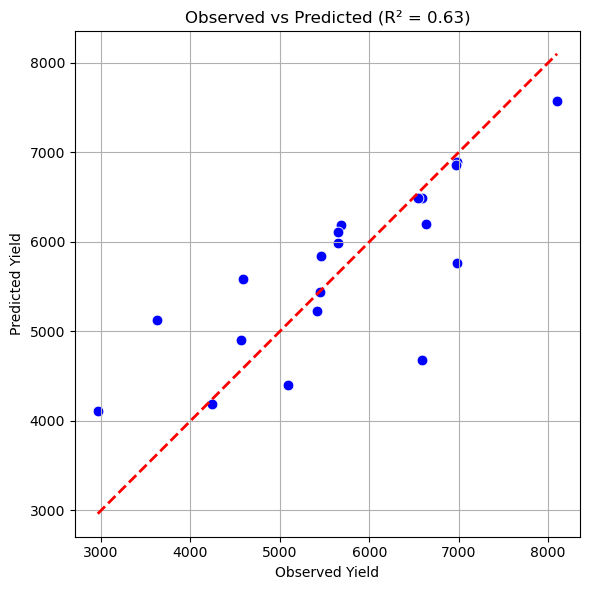

In [59]:
# 7️ Observed vs Predicted Scatter Plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Observed Yield')
plt.ylabel('Predicted Yield')
plt.title(f'Observed vs Predicted (R² = {r2:.2f})')
plt.grid(True)
plt.tight_layout()
plt.show()

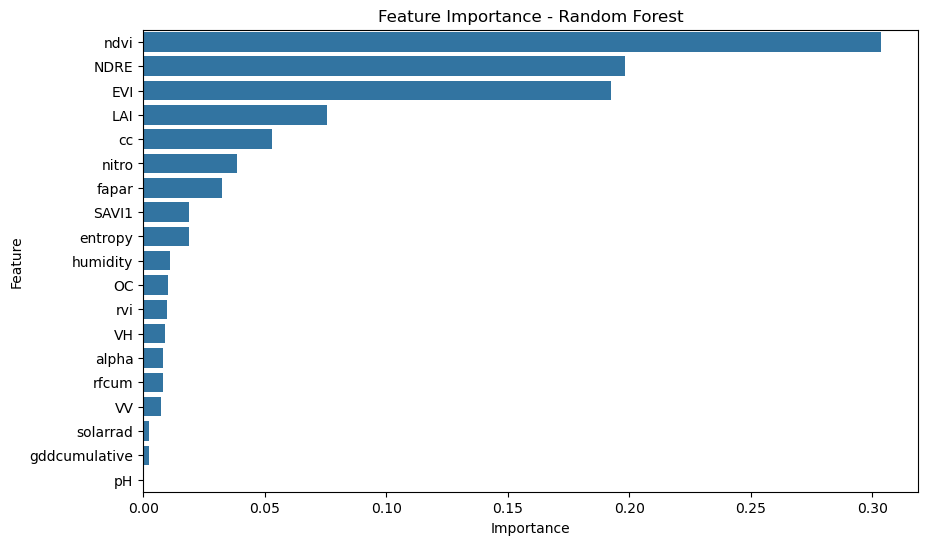

In [60]:
# 8️ Feature Importance Plot
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()

In [61]:
# 9️ Raster Alignment Function
def align_rasters(raster_paths, reference_meta):
    aligned_rasters = []
    for raster_file in raster_paths:
        with rasterio.open(raster_file) as src:
            data = src.read(1, out_shape=(reference_meta['height'], reference_meta['width']),
                            resampling=Resampling.bilinear)
            aligned_rasters.append(data)
    return np.array(aligned_rasters)

In [62]:
import pandas as pd

df = pd.read_csv("C:/PhD/yield/trail2/trail0603/trail2804/extracted3004.csv")
print(df.columns.tolist())

['yield', 'ndvi', 'NDRE', 'EVI', 'SAVI1', 'fapar', 'LAI', 'VH', 'VV', 'entropy', 'alpha', 'rvi', 'rfcum', 'humidity', 'solarrad', 'gddcumulative', 'cc', 'nitro', 'pH', 'OC']


In [ ]:
# Import necessary packages
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Function 1: Inspect all input rasters
def inspect_rasters(raster_dir, feature_names):
    """Inspect each raster's basic properties: CRS, resolution, min, max, mean, NoData."""
    print("\n Inspecting Input Raster Files:\n")
    
    for feature in feature_names:
        raster_path = os.path.join(raster_dir, f"{feature}.tif")
        try:
            with rasterio.open(raster_path) as src:
                data = src.read(1)

                print(f"Raster: {feature}")
                print(f" - CRS: {src.crs}")
                print(f" - Resolution: {src.res}")
                print(f" - Shape: {src.width} x {src.height}")
                print(f" - Min Value: {np.nanmin(data):.2f}")
                print(f" - Max Value: {np.nanmax(data):.2f}")
                print(f" - Mean Value: {np.nanmean(data):.2f}")
                print(f" - NoData Value: {src.nodata}")
                print("-"*50)
        
        except Exception as e:
            print(f" Could not read {feature}.tif: {e}")
            continue

#  Function 2: Align rasters
def align_rasters(raster_paths, reference_meta):
    """Align all rasters to the same resolution and size."""
    aligned_rasters = []
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            data = src.read(
                1, out_shape=(reference_meta['height'], reference_meta['width']),
                resampling=Resampling.bilinear
            )
            aligned_rasters.append(data)
    return np.array(aligned_rasters)

#  Function 3: Predict spatial yield map
def predict_spatial_yield(raster_dir, model, scaler, feature_names, output_path):
    """Predict yield spatially across all raster pixels."""
    raster_paths = [os.path.join(raster_dir, f"{f}.tif") for f in feature_names]

    # Inspect rasters first
    inspect_rasters(raster_dir, feature_names)

    # Load reference metadata
    with rasterio.open(raster_paths[0]) as src:
        reference_meta = src.meta
        reference_meta.update(dtype=rasterio.float32, count=1)

    # Align all rasters
    aligned_rasters = align_rasters(raster_paths, reference_meta)
    height, width = aligned_rasters.shape[1:]
    raster_stack_flat = aligned_rasters.reshape(aligned_rasters.shape[0], -1).T

    # Cleaning step
    raster_stack_flat = np.nan_to_num(raster_stack_flat, nan=0.0, posinf=0.0, neginf=0.0)
    raster_stack_flat = np.clip(raster_stack_flat, -1e3, 1e3)

    # Print raster stack summary
    print("\n Raster Stack Summary Before Scaling and Prediction:")
    print(f"Minimum: {np.min(raster_stack_flat):.2f}")
    print(f"Maximum: {np.max(raster_stack_flat):.2f}")
    print(f"Mean: {np.mean(raster_stack_flat):.2f}")
    print(f"Standard Deviation: {np.std(raster_stack_flat):.2f}")

    # Normalize using same scaler
    raster_stack_flat = scaler.transform(raster_stack_flat)

    # Predict
    yield_prediction_flat = model.predict(raster_stack_flat)
    yield_prediction = yield_prediction_flat.reshape(height, width)

    # Save the predicted map
    with rasterio.open(output_path, "w", **reference_meta) as dest:
        dest.write(yield_prediction.astype(rasterio.float32), 1)

    print(f"\n Predicted spatial yield map saved at: {output_path}")



# Define paths
raster_dir = r"C:\Users\neela\Desktop\2025\Crop Predicion\DATA"  # Folder containing input rasters
output_yield_tiff = r"C:\Users\neela\Desktop\2025\Crop Predicion\DATA\spatial_yield_prediction3.tif"  #  Output prediction path

# Define feature names (raster names without .tif)
feature_names = ['ndvi', 'NDRE', 'EVI', 'SAVI1', 'fapar', 'LAI', 'VH', 'VV', 'entropy', 'alpha', 'rvi', 'rfcum', 'humidity', 'solarrad', 'gddcumulative', 'cc', 'nitro', 'pH', 'OC']


# Load your CSV (already processed)
df = pd.read_csv(r"C:\Users\neela\Desktop\2025\Crop Predicion\DATA\extracted3004.csv")  # Your training data

# Prepare X and y
X = df[feature_names]
y = df['yield']

# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Final spatial yield prediction
predict_spatial_yield(raster_dir, rf_model, scaler, feature_names, output_yield_tiff)

import pickle

# Save model
with open("yield_model_oj.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save scaler
with open("yield_scaler_oj.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")






 Inspecting Input Raster Files:

Raster: ndvi
 - CRS: EPSG:32644
 - Resolution: (10.0, 10.0)
 - Shape: 2210 x 3356
 - Min Value: -340282346638528859811704183484516925440.00
 - Max Value: 0.73
 - Mean Value: -inf
 - NoData Value: -3.4028234663852886e+38
--------------------------------------------------
Raster: NDRE
 - CRS: EPSG:32644
 - Resolution: (10.0, 10.0)
 - Shape: 2210 x 3356
 - Min Value: -340282346638528859811704183484516925440.00
 - Max Value: 0.81
 - Mean Value: -inf
 - NoData Value: -3.4028234663852886e+38
--------------------------------------------------


C:\Users\neela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Raster: EVI
 - CRS: EPSG:32644
 - Resolution: (10.0, 10.0)
 - Shape: 2210 x 3356
 - Min Value: -340282346638528859811704183484516925440.00
 - Max Value: 1.00
 - Mean Value: -inf
 - NoData Value: -3.4028234663852886e+38
--------------------------------------------------
Raster: SAVI1
 - CRS: EPSG:32644
 - Resolution: (10.0, 10.0)
 - Shape: 2210 x 3356
 - Min Value: -179769313486231570814527423731704356798070567525844996598917476803157260780028538760589558632766878171540458953514382464234321326889464182768467546703537516986049910576551282076245490090389328944075868508455133942304583236903222948165808559332123348274797826204144723168738177180919299881250404026184124858368.00
 - Max Value: 1.50
 - Mean Value: -inf
 - NoData Value: -1.7976931348623157e+308
--------------------------------------------------
Raster: fapar
 - CRS: EPSG:32644
 - Resolution: (10.0, 10.0)
 - Shape: 2210 x 3356
 - Min Value: -340282346638528859811704183484516925440.00
 - Max Value: 0.56
 - Mean Value: -inf
 - NoDa

C:\Users\neela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



 Predicted spatial yield map saved at: C:\Users\neela\Desktop\2025\Crop Predicion\DATA\spatial_yield_prediction3.tif
Model and scaler saved successfully!


📊 Pearson Correlation with Yield:
rvi              0.707849
alpha            0.475327
entropy          0.412504
ndvi             0.222441
EVI              0.216636
SAVI1            0.211578
NDRE             0.194609
LAI              0.165407
rfcum            0.163592
nitro            0.052013
fapar            0.029022
gddcumulative    0.022320
VV              -0.005251
pH              -0.025248
solarrad        -0.057639
VH              -0.063803
OC              -0.082426
humidity        -0.096032
cc              -0.097489
Name: yield, dtype: float64


C:\Users\neela\AppData\Local\Temp\ipykernel_21024\2280358048.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")


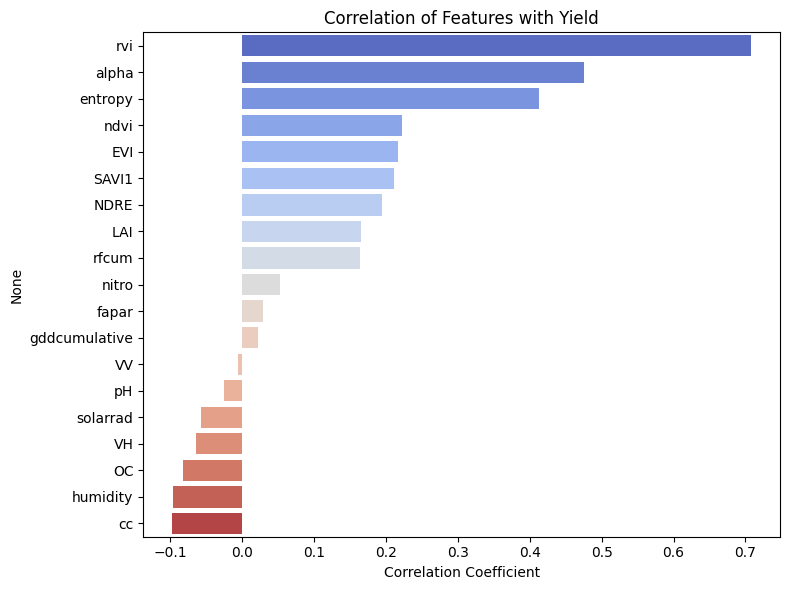

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset (if not already loaded)
df = pd.read_csv(r"C:\Users\neela\Desktop\2025\Crop Predicion\DATA\extracted3004.csv")


# Compute correlation with 'yield'
correlations = df.corr()['yield'].drop('yield').sort_values(ascending=False)

# Display correlation values
print("📊 Pearson Correlation with Yield:")
print(correlations)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")
plt.xlabel("Correlation Coefficient")
plt.title("Correlation of Features with Yield")
plt.tight_layout()
plt.show()


In [16]:
correlations = df.corr()['yield'].drop('yield').sort_values()

plt.figure(figsize=(8, 6))
plt.stem(correlations.index, correlations.values, use_line_collection=True)
plt.xticks(rotation=90)
plt.ylabel("Correlation")
plt.title("Lollipop Plot: Feature Correlation with Yield")
plt.grid(True)
plt.tight_layout()
plt.show()

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 800x600 with 0 Axes>